## Fase 1: Comprensión del Negocio

Repositorio: https://in.investing.com/commodities/gold-mini-historical-data

### Empresa: GoldTech
GoldTech se especializa en desarrollar software para inversiones en oro. Ofrecen plataformas tecnológicas que permiten a los usuarios gestionar y optimizar sus inversiones en metales preciosos. Esto incluye herramientas para el seguimiento de precios, análisis de mercado, y ejecución de transacciones de compra y venta de oro.

### Misión:
"Ser el socio líder en inversiones de metales preciosos, proporcionando soluciones tecnológicas innovadoras que maximicen el rendimiento y minimicen el riesgo para nuestros clientes."

### Visión:
"Transformar la inversión en oro mediante la integración de tecnología avanzada y análisis predictivo, convirtiéndonos en el referente global para inversiones seguras y rentables en metales preciosos para 2026."


### Objetivo Comercial:
Incrementar en un 25% el volumen de inversiones gestionadas en oro durante el próximo año fiscal, minimizando el riesgo de pérdida para los clientes.

### Objetivo de Minería de Datos:
Pronosticar los precios del oro con una precisión del 85% en un horizonte temporal de 90 días.

### KPIs:

#### Comerciales:

Volumen de inversiones gestionadas


#### Minería de datos:

RMSE (Root Mean Square Error) 

MAE (Mean Absolute Error) 

### Fase 2: Comprensión de los Datos

In [220]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [221]:
df = pd.read_csv('Gold Futures Historical Data.csv')
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,01/10/2005,419.70,419.90,422.30,418.40,34.18K,0.05%
1,01/11/2005,422.40,419.60,423.30,419.60,46.90K,0.64%
2,01/12/2005,426.60,423.00,428.30,421.10,64.04K,0.99%
3,01/13/2005,425.10,426.60,427.30,423.60,35.09K,-0.35%
4,01/14/2005,423.30,422.90,423.30,422.70,30.93K,-0.42%


__Fecha__ (Fecha)

Fecha en formato estándar

__Precio__ (Numérico discreto)

Es el precio de cierre que puede considerarse como el precio final

__Apertura__ (Numérico discreto)

Precio al momento de la apertura del mercado en ese día

__Máximo__ (Numérico discreto)

Precio más alto durante todo el día

__Mínimo__ (Numérico discreto)

Precio más bajo durante todo el día

__Volumen__ (Numérico continuo)

Volumen negociado

__Cambio %__ (Numérico continuo)

Porcentaje de cambio respecto al precio anterior


In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      5000 non-null   object
 1   Price     5000 non-null   object
 2   Open      5000 non-null   object
 3   High      5000 non-null   object
 4   Low       5000 non-null   object
 5   Vol.      4997 non-null   object
 6   Change %  5000 non-null   object
dtypes: object(7)
memory usage: 273.6+ KB


In [223]:
df.isnull().sum()

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        3
Change %    0
dtype: int64

In [224]:
df.shape

(5000, 7)

### Fase 3: Preparación de los datos

In [225]:
# Reemplazar valores nulos en la columna 'Vol.' con 0K
df['Vol.'] = df['Vol.'].fillna("0K")

In [226]:
df.isnull().sum()

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64

In [227]:
df

,Date,Price,Open,High,Low,Vol.,Change %
0,01/10/2005,419.70,419.90,422.30,418.40,34.18K,0.05%
1,01/11/2005,422.40,419.60,423.30,419.60,46.90K,0.64%
2,01/12/2005,426.60,423.00,428.30,421.10,64.04K,0.99%
3,01/13/2005,425.10,426.60,427.30,423.60,35.09K,-0.35%
4,01/14/2005,423.30,422.90,423.30,422.70,30.93K,-0.42%
...,...,...,...,...,...,...,...
4995,08/27/2024,"2,575.20","2,575.00","2,583.10","2,562.20",1.25K,-0.10%
4996,08/28/2024,"2,560.00","2,582.90","2,585.40","2,550.20",2.32K,-0.59%
4997,08/29/2024,"2,582.70","2,562.20","2,584.40","2,560.00",1.67K,0.89%
4998,08/30/2024,"2,549.80","2,576.50","2,581.70","2,549.10",5.27K,-1.27%


In [228]:
# Rename columns
df.rename(columns={
    'Price': 'Price',
    'Open': 'Open',
    'High': 'High',
    'Low': 'Low',
    'Vol.': 'Volume',
    'Change %': 'Chg%'
}, inplace=True)

# Clean 'Volume' column: remove 'K', handle decimal points, and convert to numeric
df['Volume'] = (
    df['Volume']
    .str.replace('K', '', regex=False)  # Remove 'K'
    .str.replace('.', '', regex=False)  # Remove the decimal point
    .astype(float)                      # Convert to float
    * 1000                              # Scale up by 1000
)

# Clean 'Chg%' column: remove '%' and convert to numeric
df['Chg%'] = df['Chg%'].str.replace('%', '', regex=False).astype(float)

# Convert numeric columns (Price, Open, High, Low) to float and optionally to int
columns_to_convert = ['Price', 'Open', 'High', 'Low']
for col in columns_to_convert:
    df[col] = df[col].str.replace(',', '', regex=False).astype(float)
    # Optional: Convert to integers if needed
    df[col] = df[col].round(0).astype(int)

# Verify changes
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5000 non-null   object 
 1   Price   5000 non-null   int32  
 2   Open    5000 non-null   int32  
 3   High    5000 non-null   int32  
 4   Low     5000 non-null   int32  
 5   Volume  5000 non-null   float64
 6   Chg%    5000 non-null   float64
dtypes: float64(2), int32(4), object(1)
memory usage: 195.4+ KB
None
         Date  Price  Open  High  Low     Volume  Chg%
0  01/10/2005    420   420   422  418  3418000.0  0.05
1  01/11/2005    422   420   423  420  4690000.0  0.64
2  01/12/2005    427   423   428  421  6404000.0  0.99
3  01/13/2005    425   427   427  424  3509000.0 -0.35
4  01/14/2005    423   423   423  423  3093000.0 -0.42


In [229]:
df.describe()

,Price,Open,High,Low,Volume,Chg%
count,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000
mean,1330.855600,1325.883400,1335.637400,1315.548000,1.210900e+07,0.042978
std,467.516222,459.917437,462.280996,457.284507,1.025810e+07,1.177405
min,414.000000,414.000000,415.000000,412.000000,0.000000e+00,-9.340000
25%,1076.000000,1075.000000,1085.000000,1068.000000,3.224750e+06,-0.470000
50%,1292.000000,1292.500000,1299.000000,1284.500000,1.161550e+07,0.040000
75%,1699.250000,1699.000000,1714.000000,1683.000000,1.787475e+07,0.610000
max,2583.000000,2583.000000,2592.000000,2567.000000,8.165300e+07,9.450000


In [230]:
# Precio promedio
precio_promedio = df['Price'].mean()

# Rango de precios
rango_precio = df['High'] - df['Low']
rango_precio_promedio = rango_precio.mean()

# Volatilidad promedio diaria
volatilidad_diaria = df['Chg%'].std()

precio_promedio, rango_precio_promedio, volatilidad_diaria

(1330.8556, 20.0894, 1.1774051673496344)

Resultados:

Precio promedio: 1330.8556

Rango de precios promedio: 20.0894

Volatilidad promedio diaria: 1.78%

In [234]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

In [235]:
df['Month']=df['Date'].dt.month_name()
df['Year']=df['Date'].dt.year
df.head()

,Date,Price,Open,High,Low,Volume,Chg%,Month,Year
0,2005-01-10,420,420,422,418,3418000.0,0.05,January,2005
1,2005-01-11,422,420,423,420,4690000.0,0.64,January,2005
2,2005-01-12,427,423,428,421,6404000.0,0.99,January,2005
3,2005-01-13,425,427,427,424,3509000.0,-0.35,January,2005
4,2005-01-14,423,423,423,423,3093000.0,-0.42,January,2005


In [236]:
#Index Date
df=df.set_index('Date')

In [237]:
df.head()

,Price,Open,High,Low,Volume,Chg%,Month,Year
Date,,,,,,,,
2005-01-10,420,420,422,418,3418000.0,0.05,January,2005
2005-01-11,422,420,423,420,4690000.0,0.64,January,2005
2005-01-12,427,423,428,421,6404000.0,0.99,January,2005
2005-01-13,425,427,427,424,3509000.0,-0.35,January,2005
2005-01-14,423,423,423,423,3093000.0,-0.42,January,2005


In [238]:
df.tail()

,Price,Open,High,Low,Volume,Chg%,Month,Year
Date,,,,,,,,
2024-08-27,2575,2575,2583,2562,125000.0,-0.10,August,2024
2024-08-28,2560,2583,2585,2550,232000.0,-0.59,August,2024
2024-08-29,2583,2562,2584,2560,167000.0,0.89,August,2024
2024-08-30,2550,2576,2582,2549,527000.0,-1.27,August,2024
2024-09-03,2545,2555,2561,2526,368000.0,-0.19,September,2024


In [239]:
df['Year'].unique()

array([2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [240]:
df['Month'].unique()

array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype=object)

In [241]:
def plot_feature(col,color):
   plt.plot(df[col],color)
   plt.title(f'Tendencia de {col}')
   plt.ylabel(f'{col}')

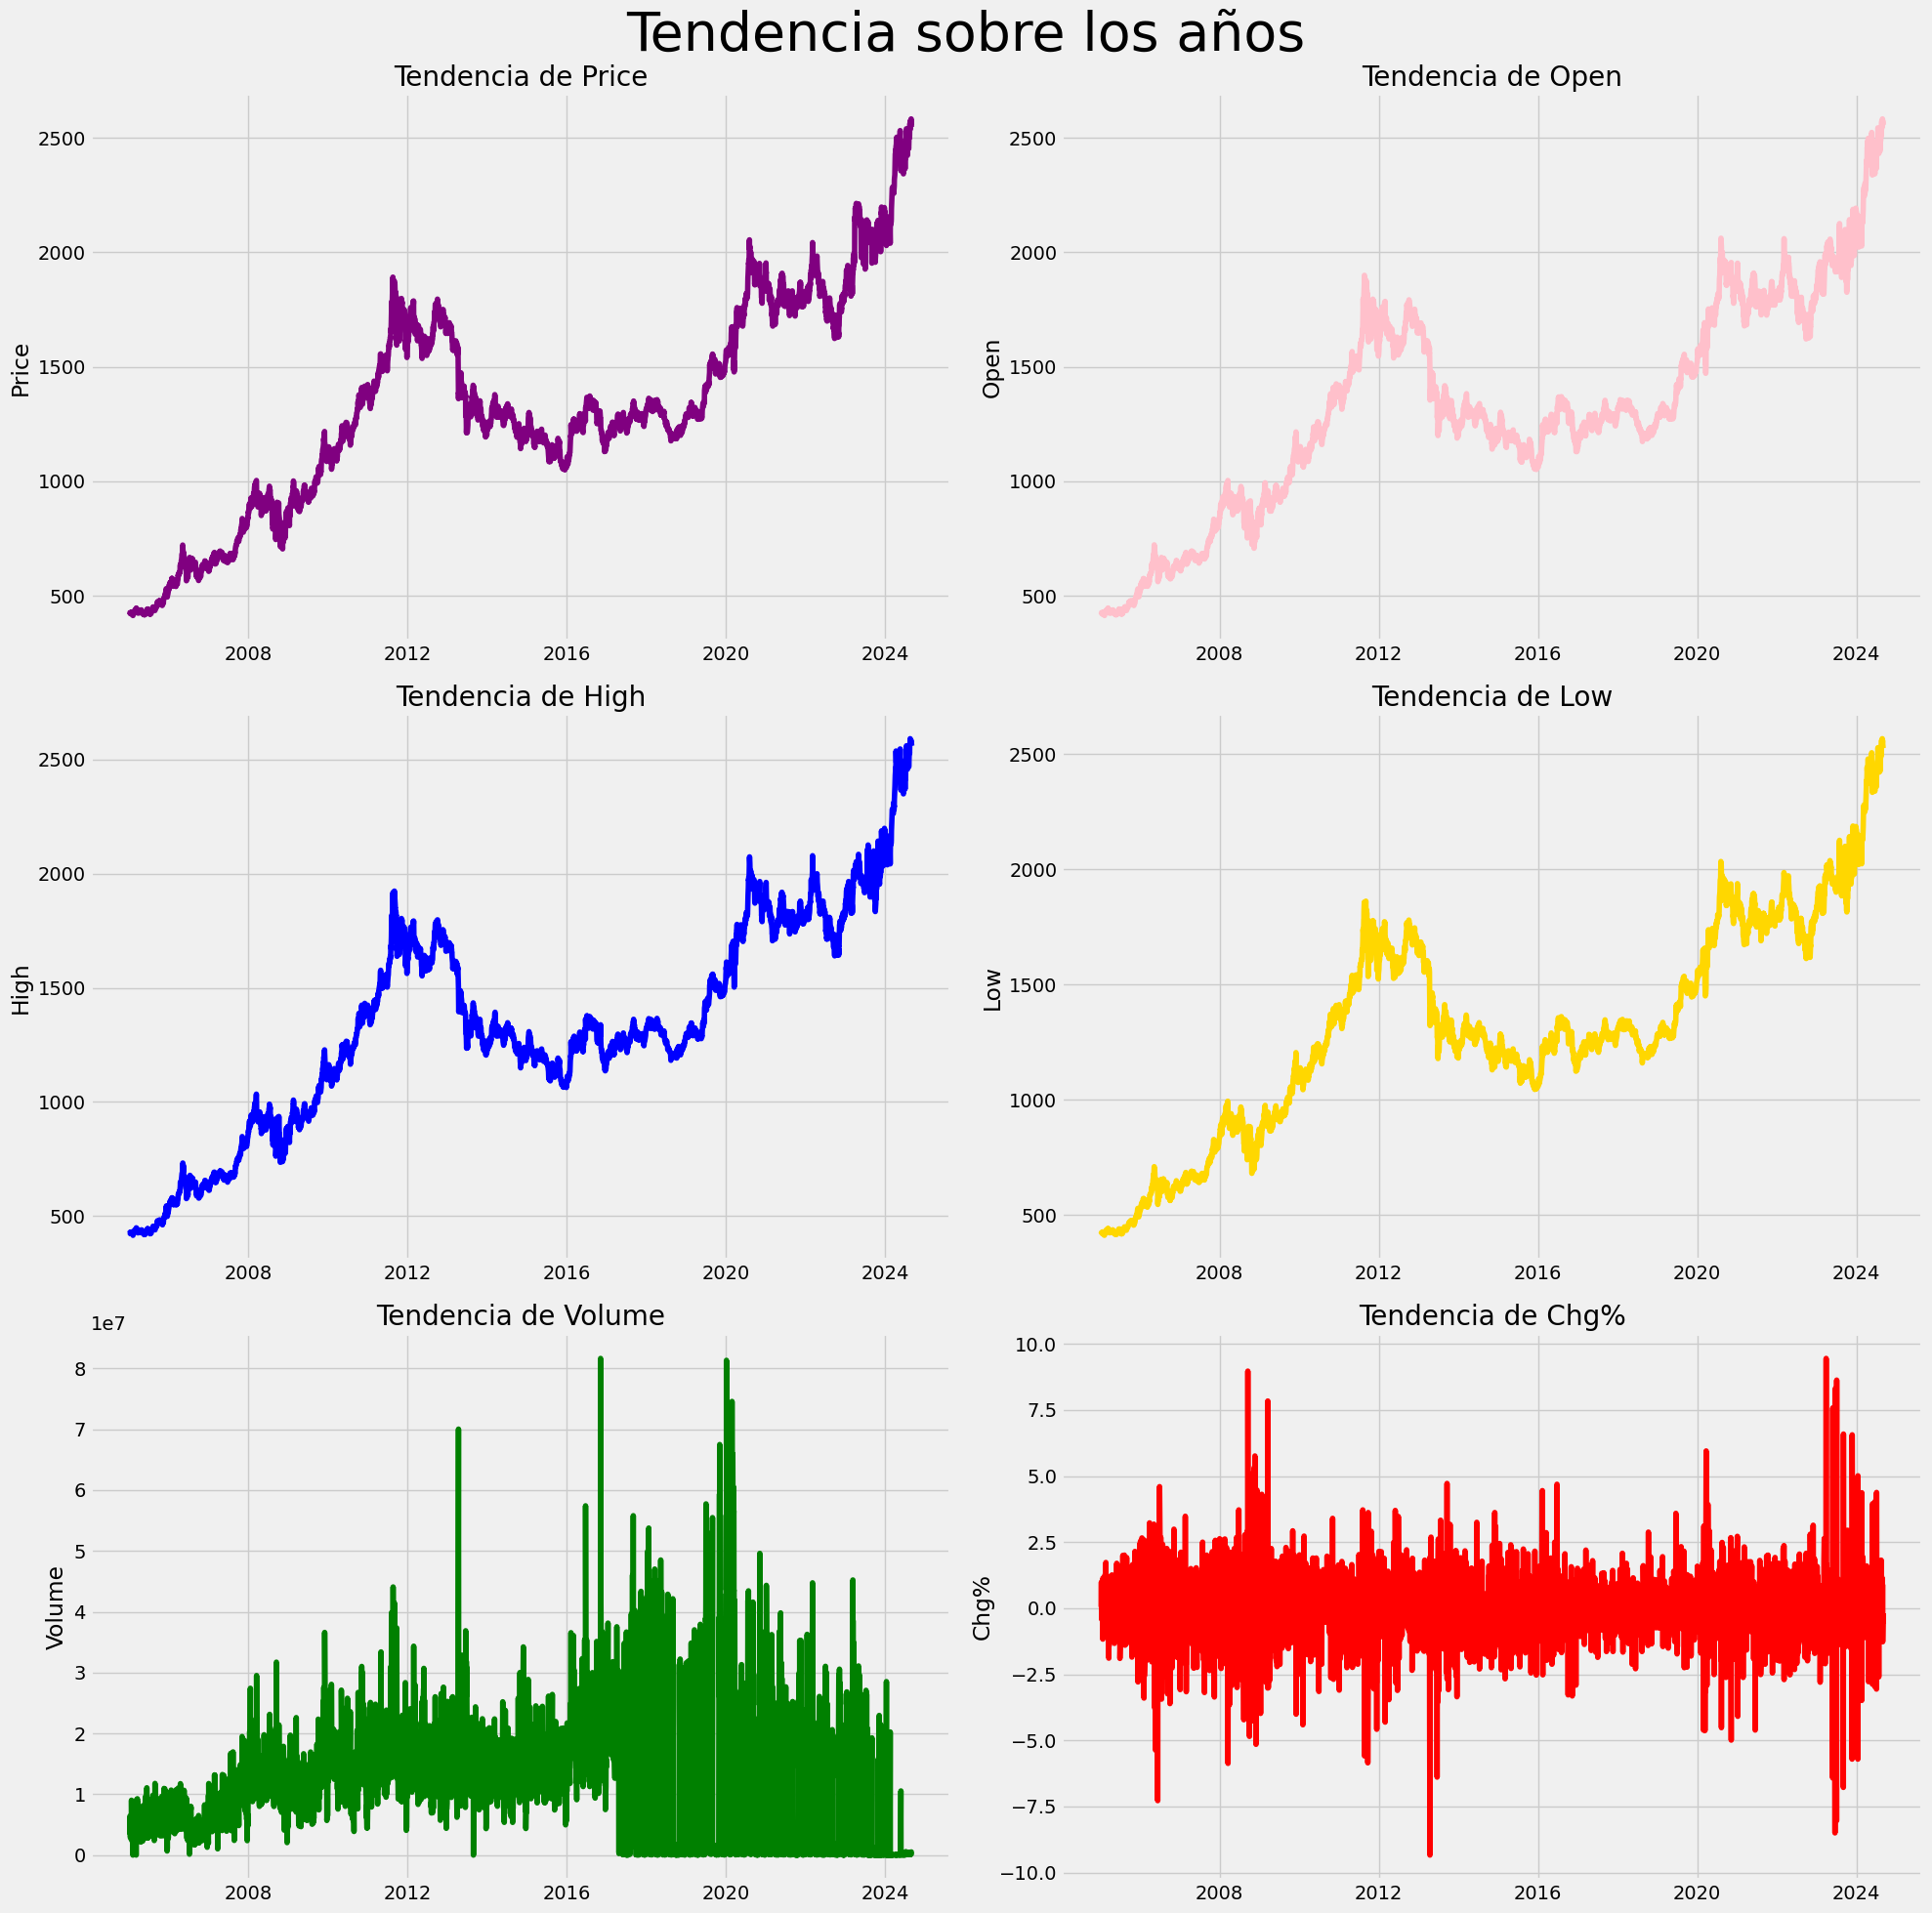

In [242]:
plt.figure(figsize=(20,20))
colors=['purple','pink','blue','gold','green','red']
plt.suptitle('Tendencia sobre los años',fontsize=40)
for i,col in enumerate(df.columns[:-2]):
    plt.subplot(3,2,i+1)
    plot_feature(col,colors[i])
plt.tight_layout()
plt.show()

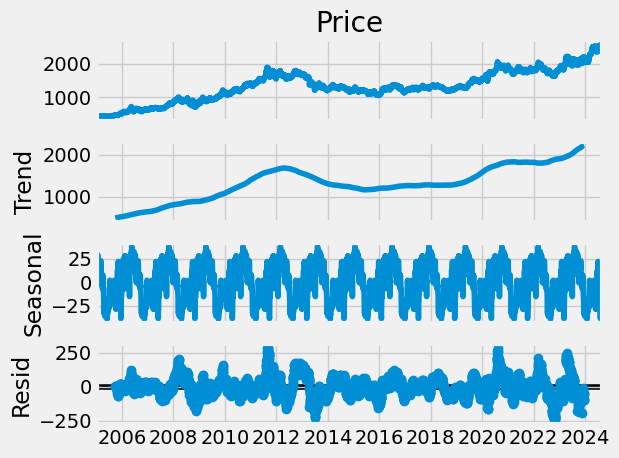

In [243]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure dates are sorted in ascending order
df = df.sort_values(by='Date', ascending=True)

# Perform seasonal decomposition
decompose = seasonal_decompose(df['Price'], model='additive', period=365)

# Plot the decomposition
decompose.plot()
plt.show()

In [244]:
#Precio total por meses
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
month_grouped=df.groupby('Month').sum()
month_grouped=month_grouped.sort_values(by='Price')
month_grouped=month_grouped.reindex(months)
month_grouped

,Price,Open,High,Low,Volume,Chg%,Year
Month,,,,,,,
January,533786,533340,537290,529484,7.124697e+09,65.19,819998
February,516978,516920,520613,513064,3.964076e+09,18.85,789724
March,577730,577709,582304,572604,7.397405e+09,18.34,882349
April,556863,553552,557625,549301,3.572742e+09,28.79,831991
May,586978,583652,587816,579032,6.734002e+09,-2.82,874336
June,572671,569357,573250,564890,3.643470e+09,-6.65,862199
July,581694,578650,582731,574576,6.563903e+09,33.05,866285
August,609403,605688,610246,601077,3.633845e+09,24.85,896451
September,523851,521770,525706,517099,4.173930e+09,-10.75,799605


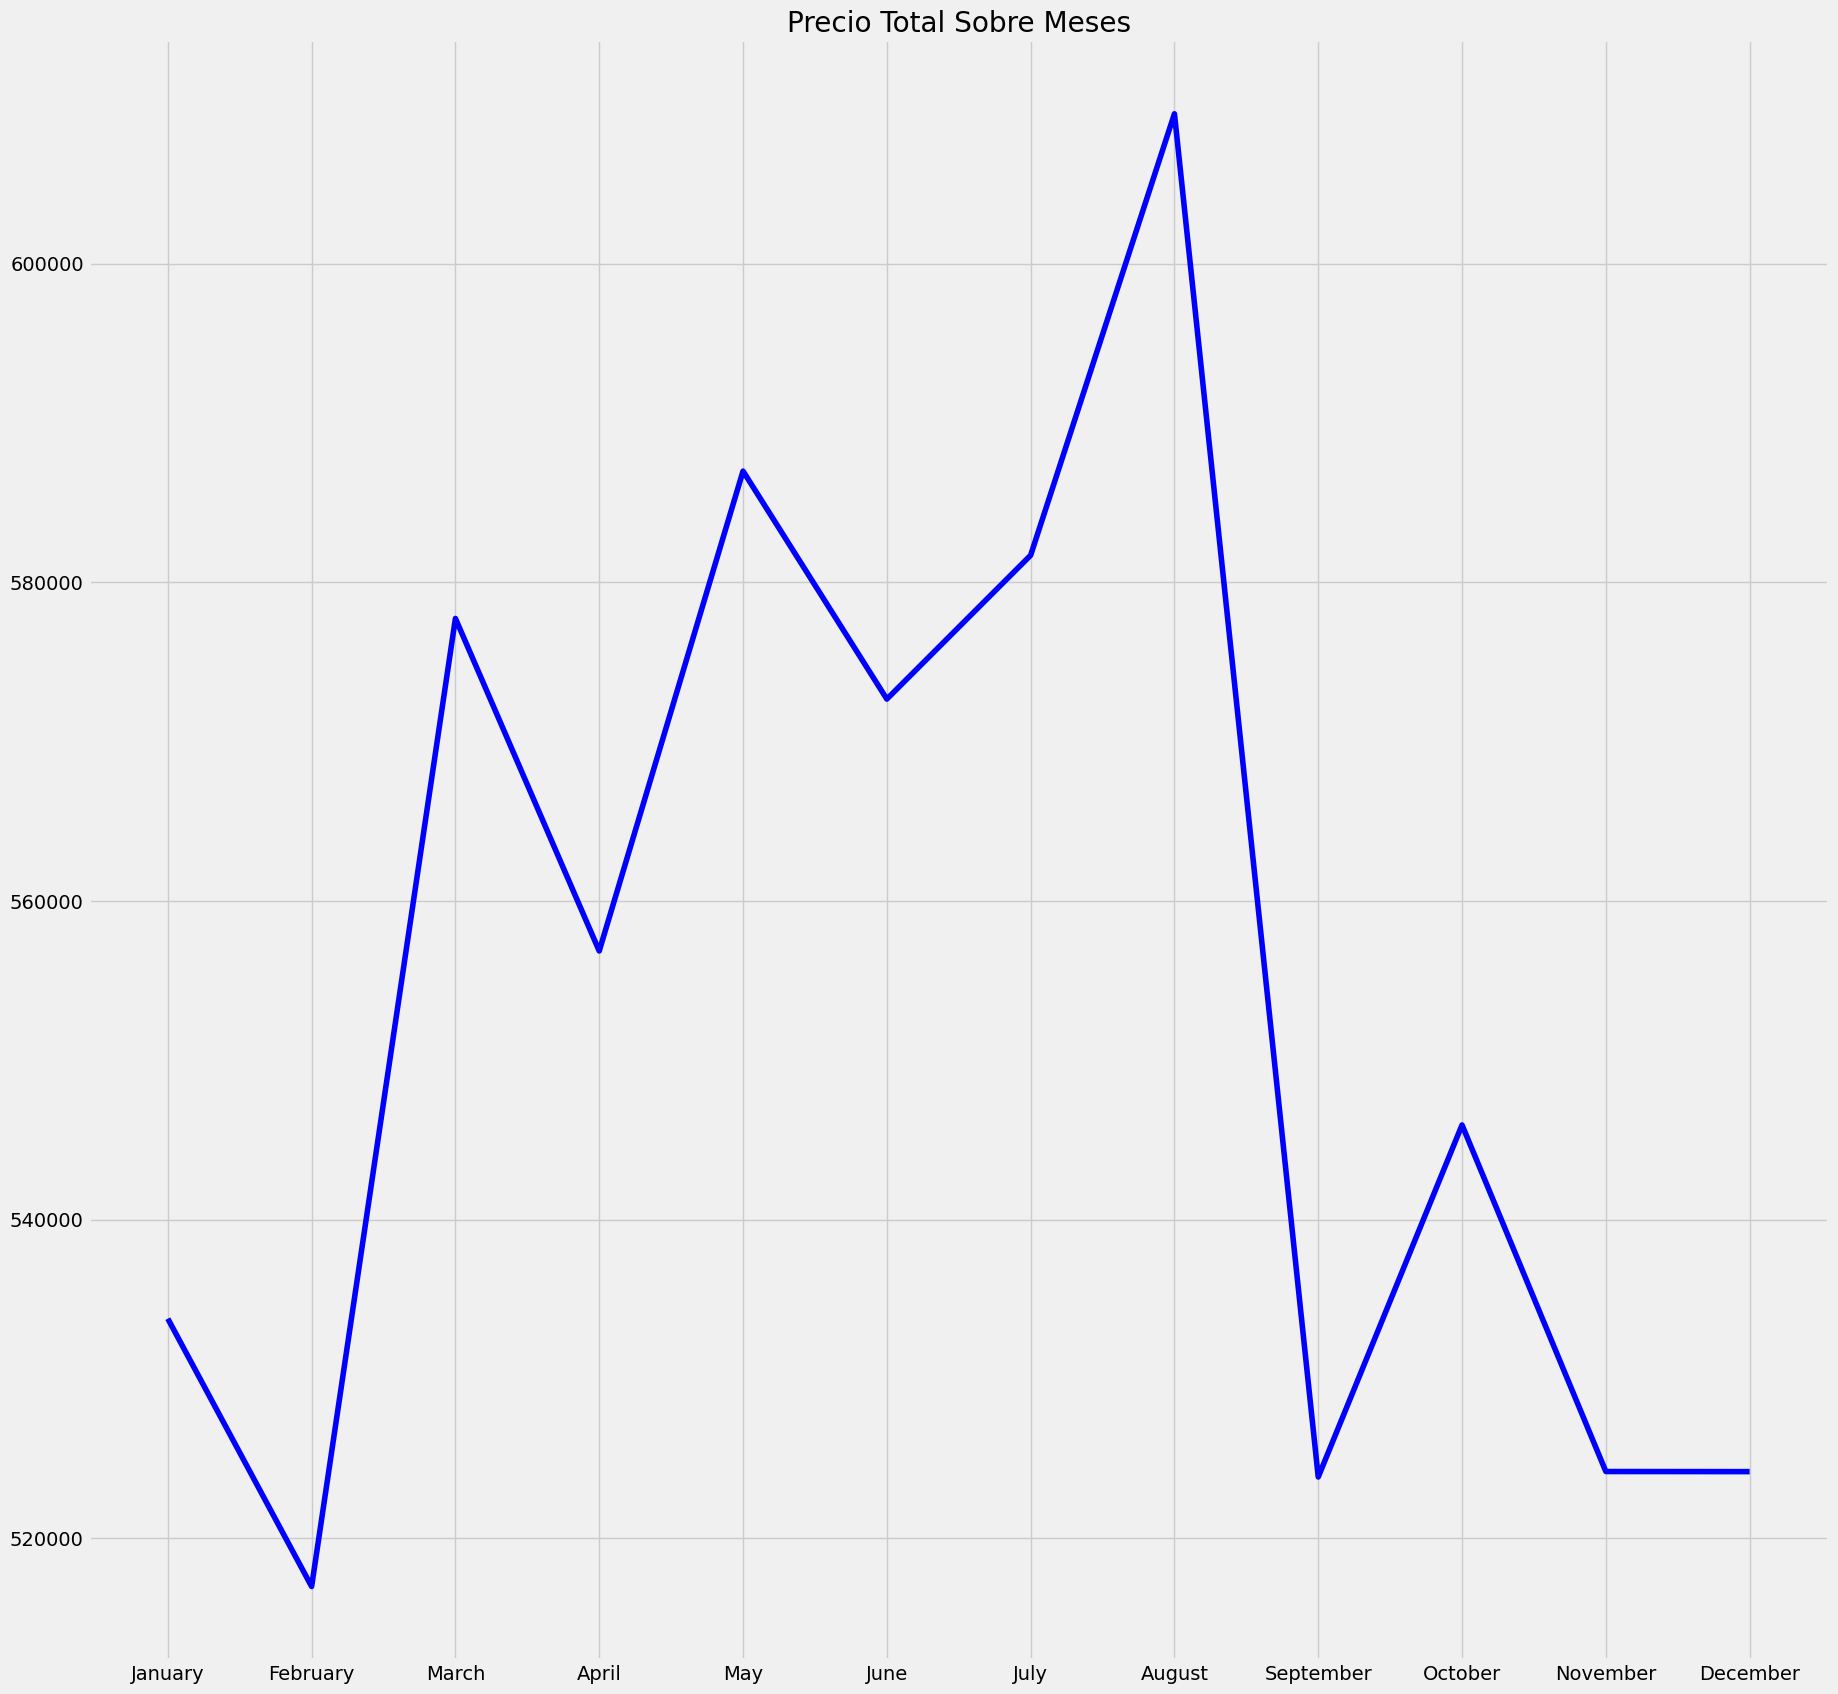

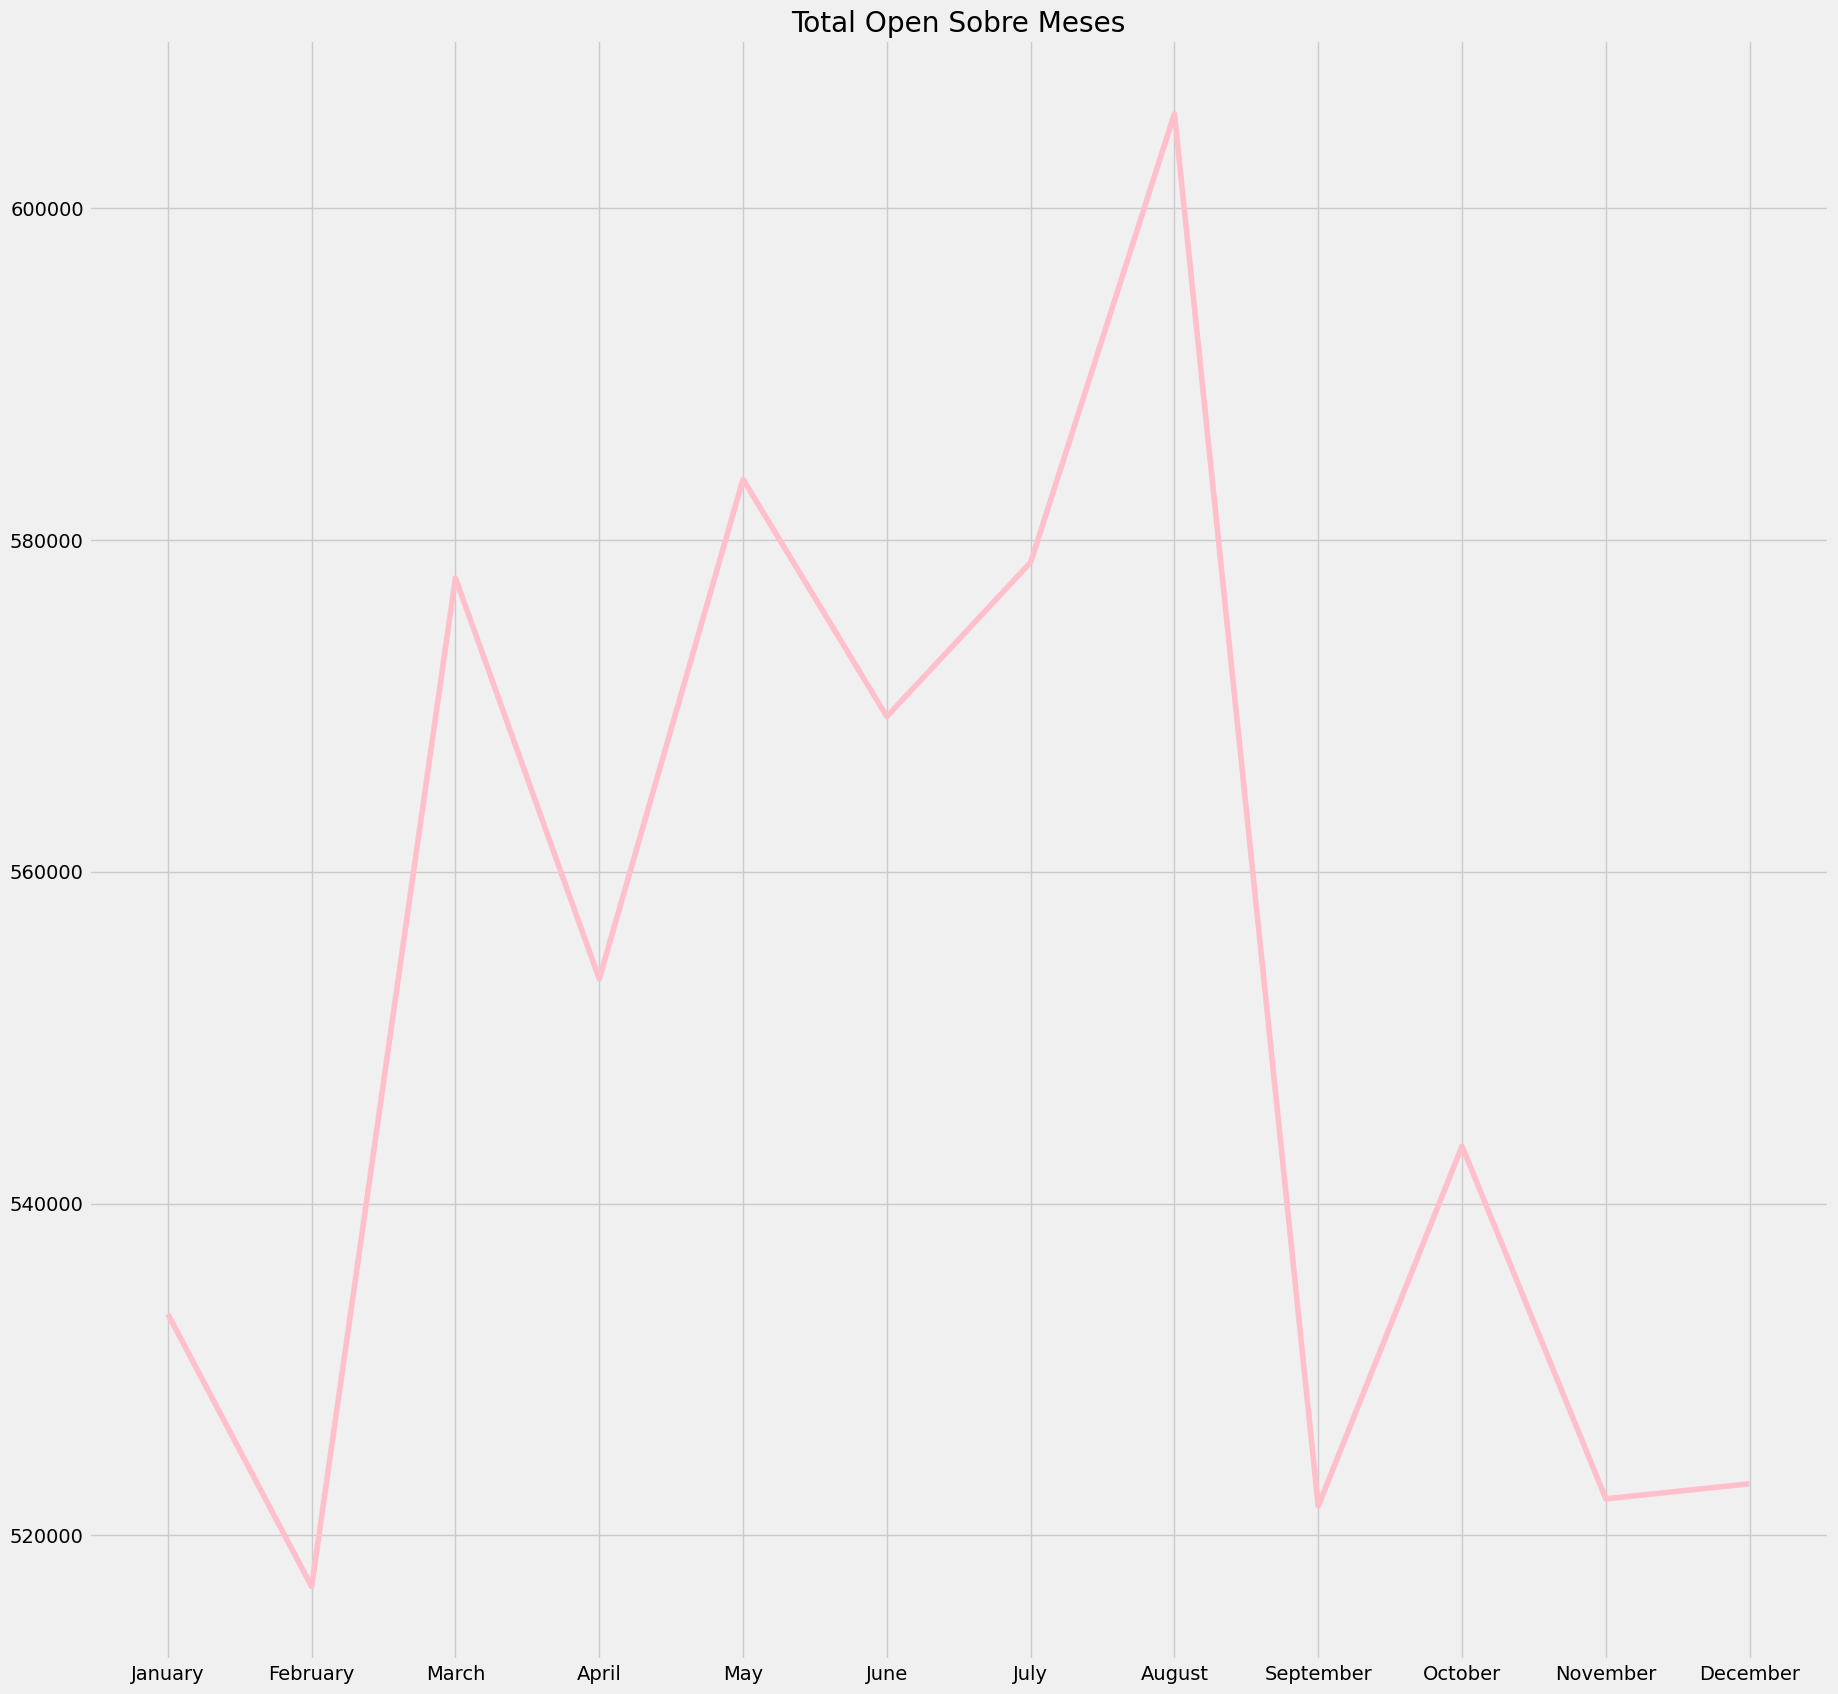

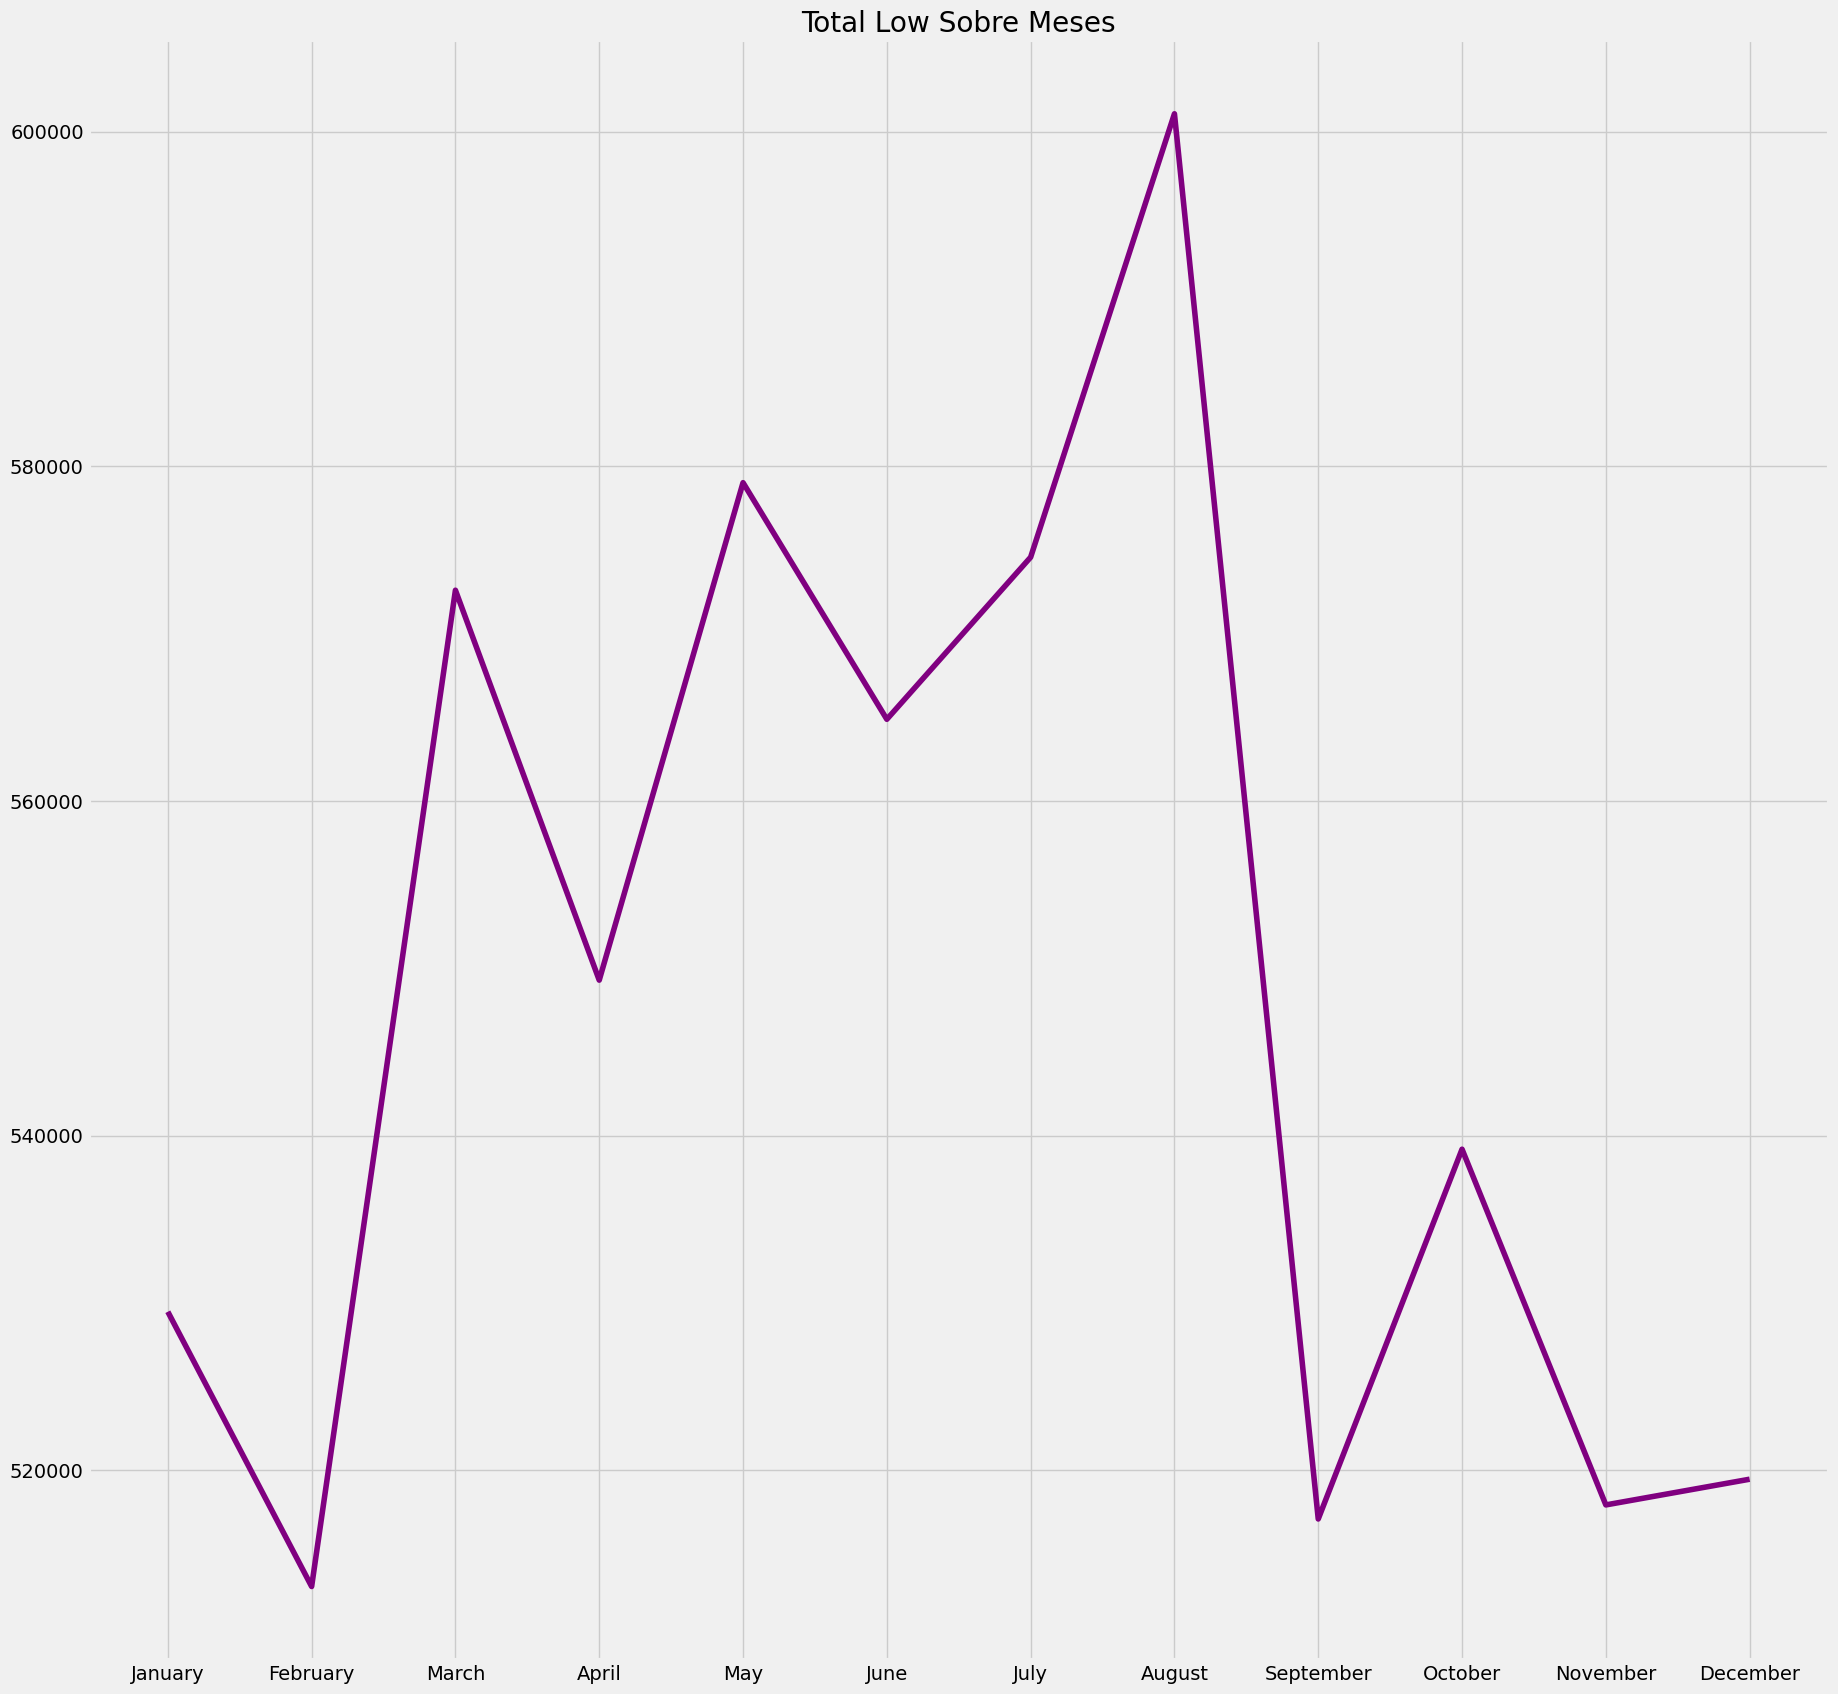

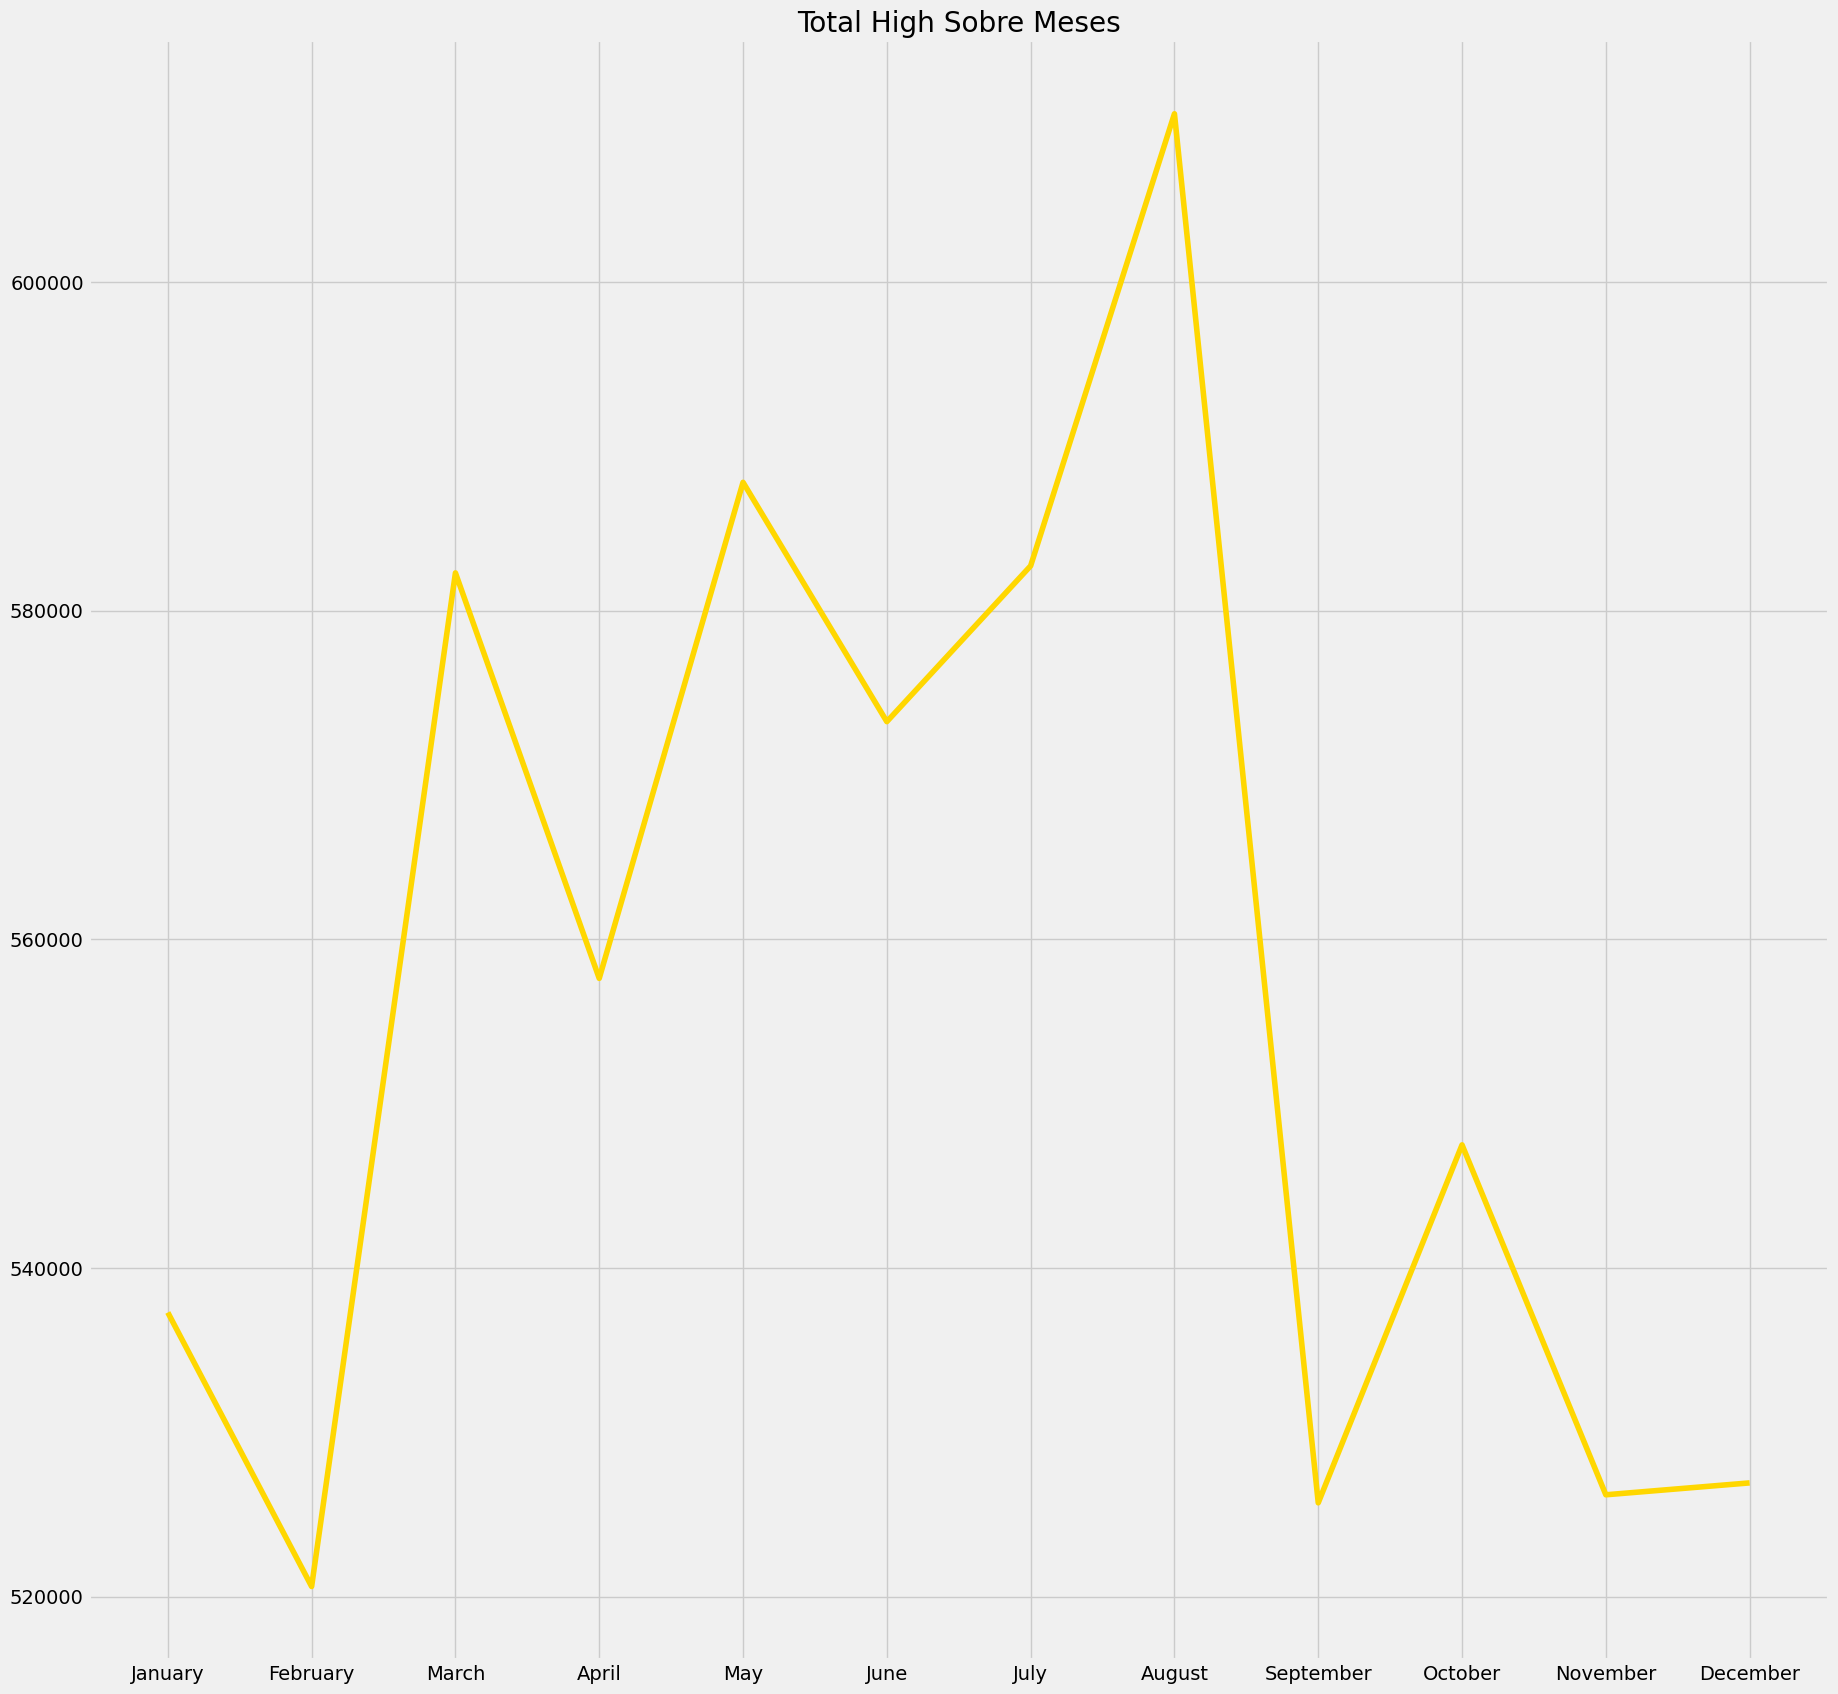

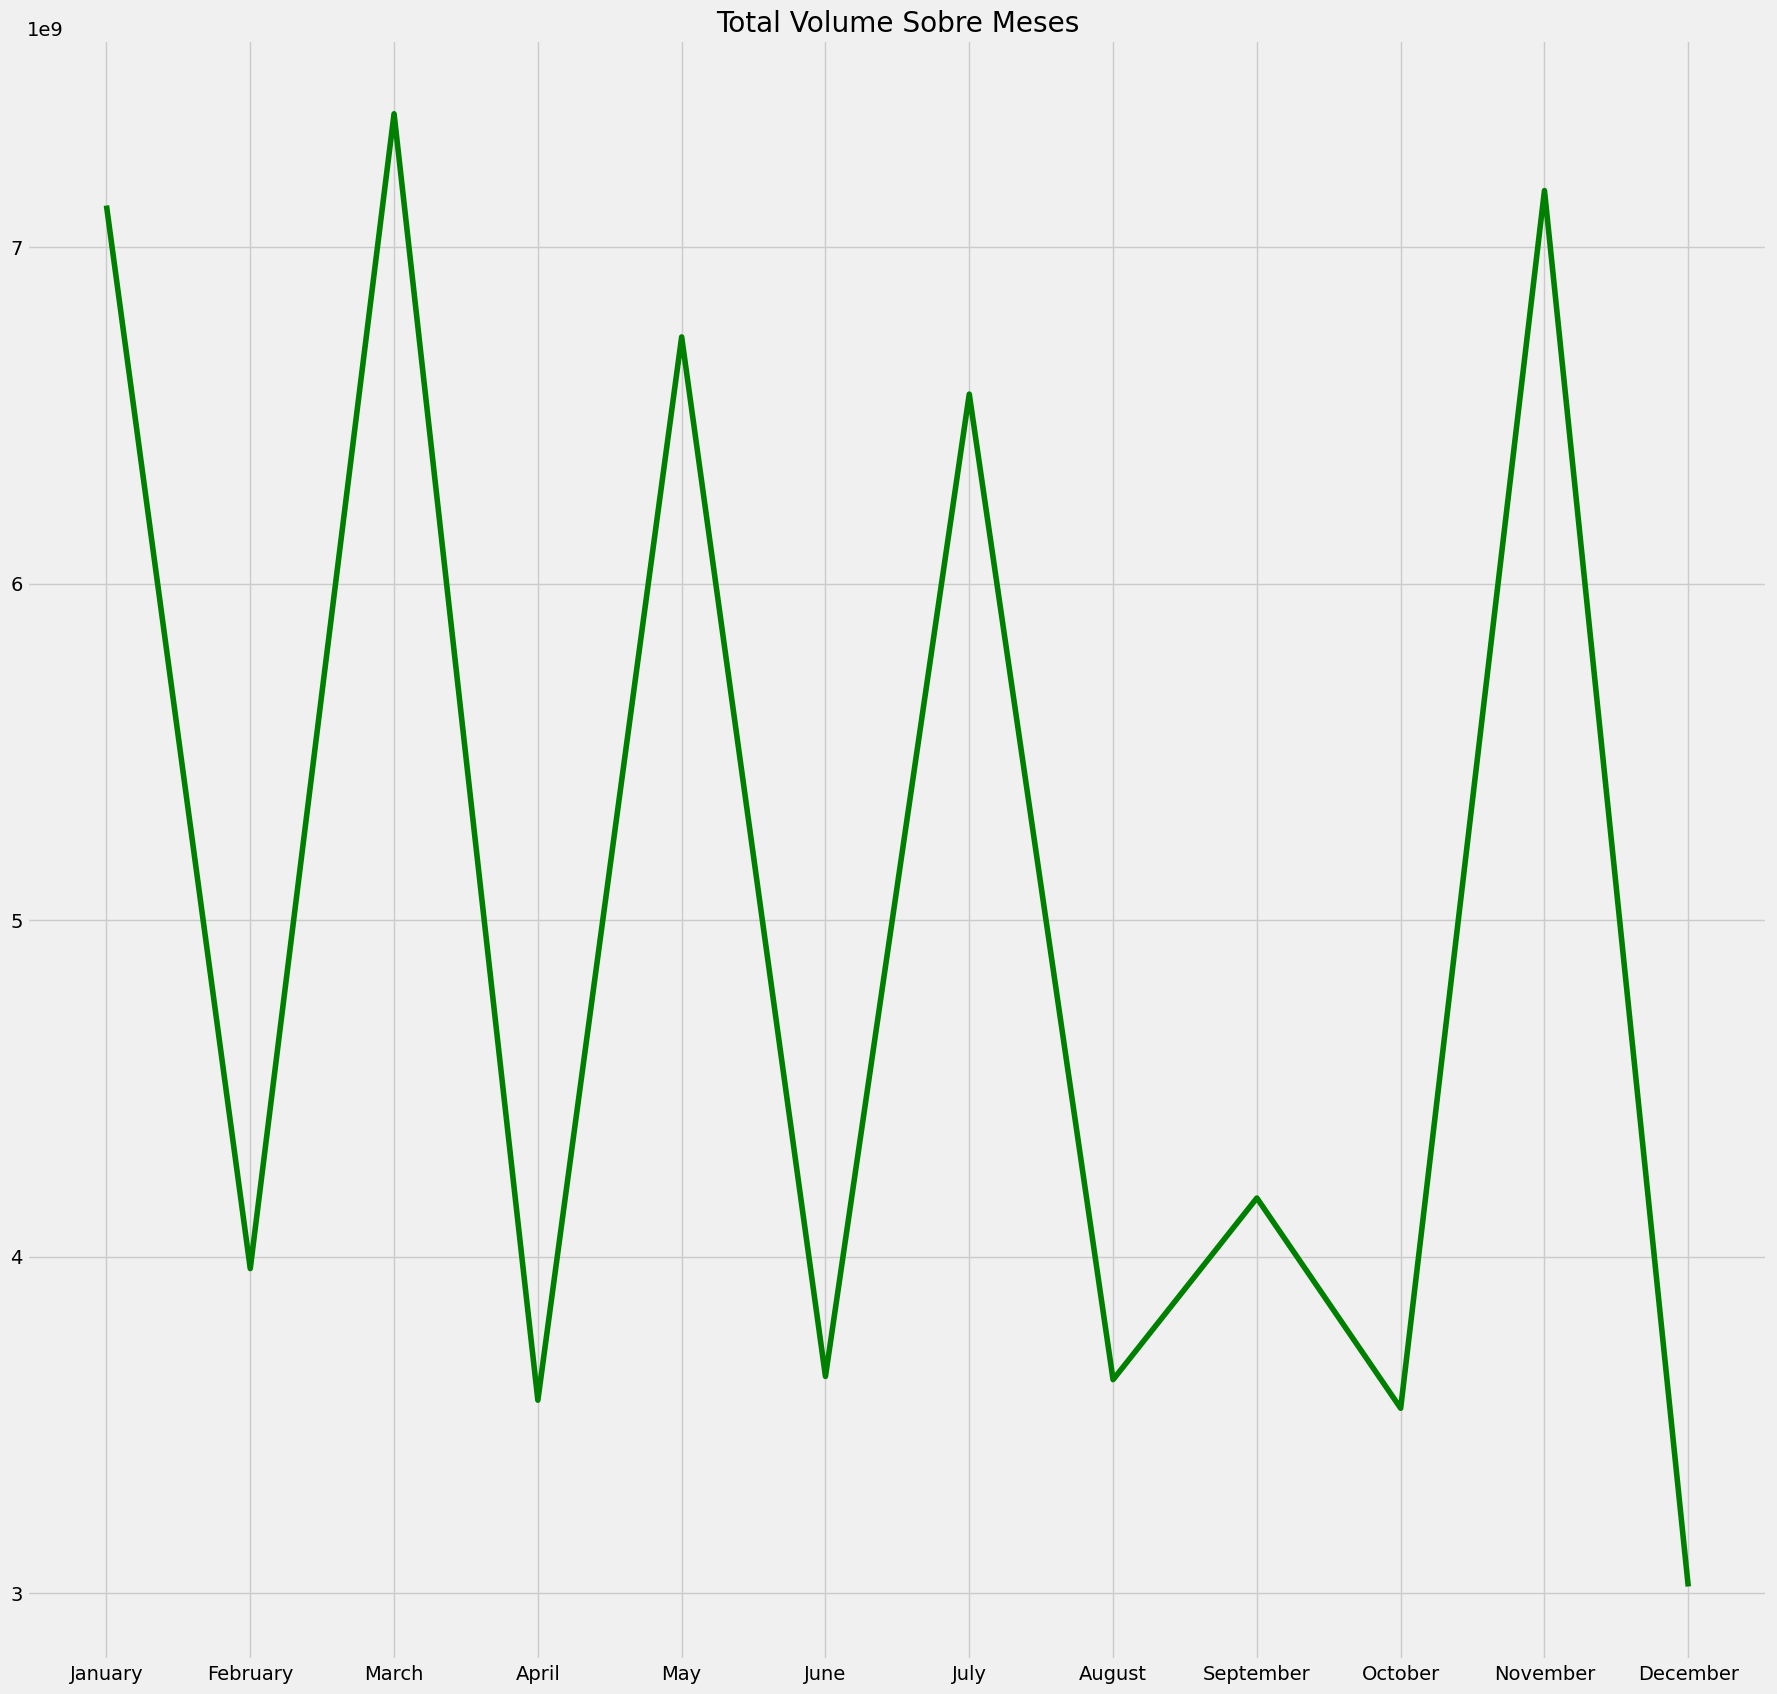

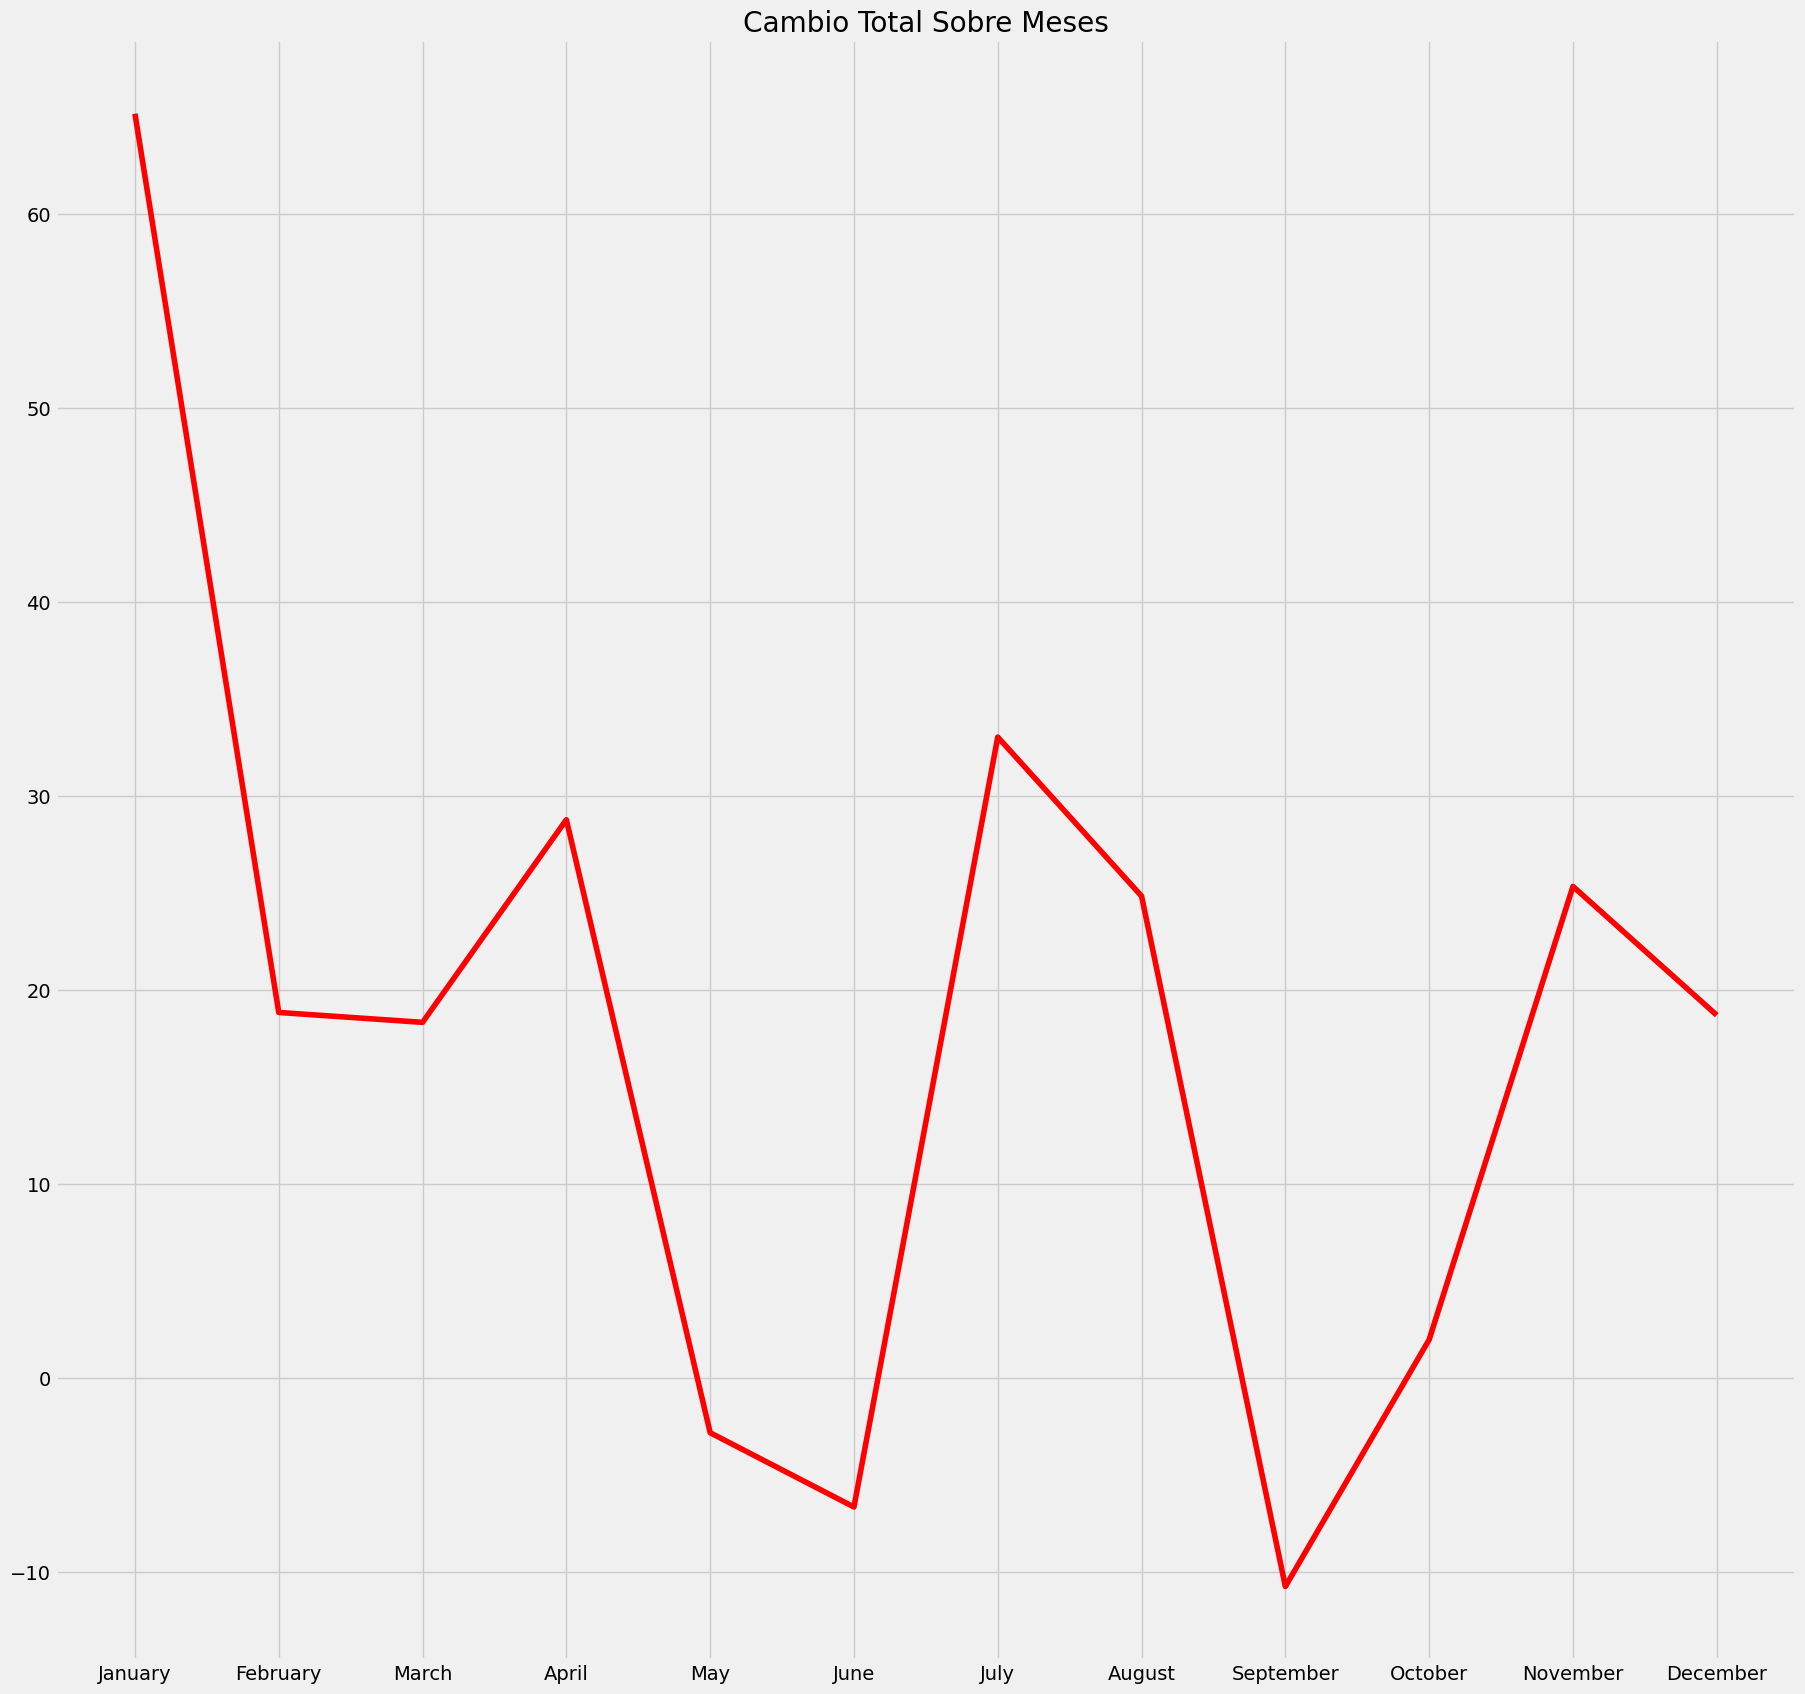

In [245]:
plt.figure(figsize=(20,20))
plt.title('Precio Total Sobre Meses')
plt.plot(month_grouped.index,month_grouped['Price'],colors[2])
plt.figure(figsize=(20,20))
plt.title('Total Open Sobre Meses')
plt.plot(month_grouped.index,month_grouped['Open'],colors[1])
plt.figure(figsize=(20,20))
plt.title('Total Low Sobre Meses')
plt.plot(month_grouped.index,month_grouped['Low'],colors[0])
plt.figure(figsize=(20,20))
plt.title('Total High Sobre Meses')
plt.plot(month_grouped.index,month_grouped['High'],colors[3])
plt.figure(figsize=(20,20))
plt.title('Total Volume Sobre Meses')
plt.plot(month_grouped.index,month_grouped['Volume'],colors[4])
plt.figure(figsize=(20,20))
plt.title('Cambio Total Sobre Meses')
plt.plot(month_grouped.index,month_grouped['Chg%'],colors[5])

In [246]:
#Precio total por años
years=df['Year'].unique()
grouped_year=df.groupby('Year',)[df.columns[:-2]].mean()
grouped_year=grouped_year.sort_values(by='Price')
grouped_year=grouped_year.reindex(years)
grouped_year

,Price,Open,High,Low,Volume,Chg%
Year,,,,,,
2005,447.577236,447.268293,450.012195,444.581301,5.248309e+06,0.090081
2006,608.076000,608.088000,614.396000,600.892000,5.169296e+06,0.093720
2007,701.316406,700.726562,706.718750,695.093750,8.248426e+06,0.112031
2008,874.152941,874.949020,887.823529,861.635294,1.309773e+07,0.039176
2009,974.964286,974.099206,984.230159,964.277778,1.183348e+07,0.095040
2010,1228.321429,1227.361111,1237.079365,1217.567460,1.488250e+07,0.108532
2011,1573.265873,1573.980159,1588.226190,1557.551587,1.685095e+07,0.047183
2012,1670.543651,1670.182540,1681.067460,1657.531746,1.493678e+07,0.031905
2013,1408.746032,1410.976190,1422.301587,1396.107143,1.625238e+07,-0.121865


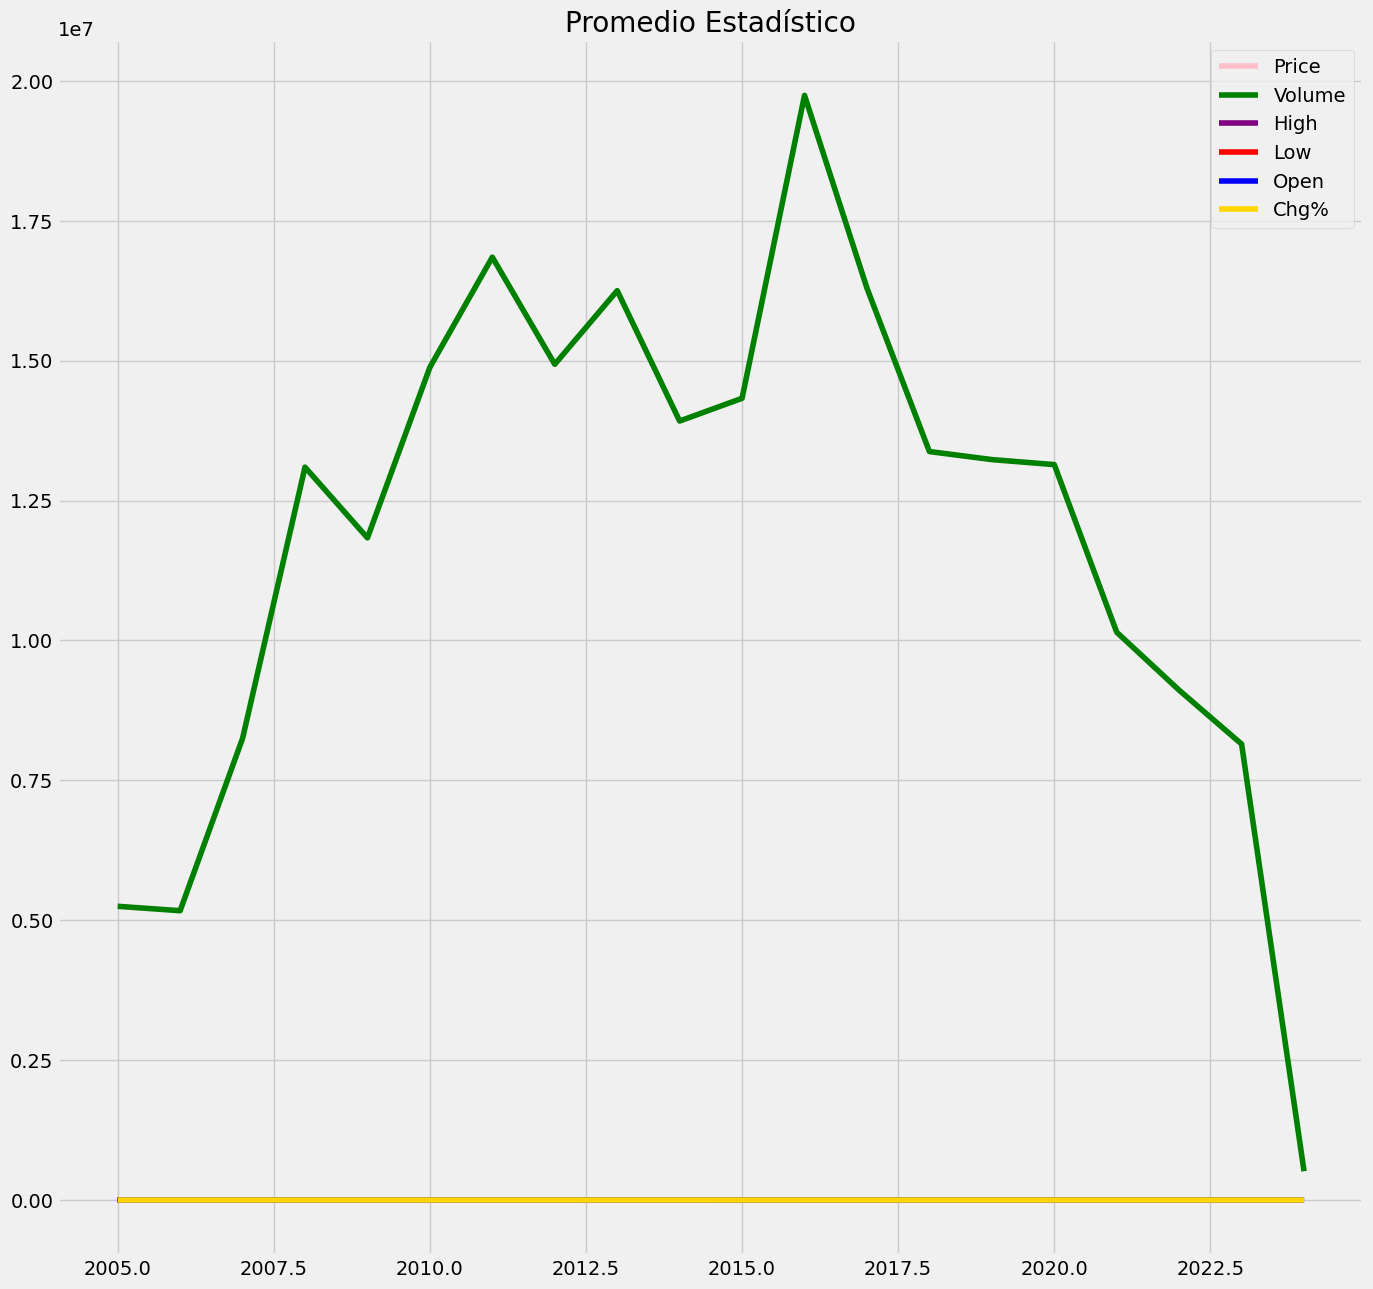

In [247]:
plt.figure(figsize=(15,15))
plt.plot(grouped_year['Price'],colors[1])
plt.plot(grouped_year['High'],colors[0])
plt.plot(grouped_year['Low'],colors[5])
plt.plot(grouped_year['Open'],colors[2])
plt.plot(grouped_year['Chg%'],colors[3])
plt.legend(['Price','Volume','High','Low','Open','Chg%'])
plt.title(f'Promedio Estadístico')
plt.show()

### Fase 4: Modelado

#### LSTM

In [305]:
# Target Column is Price
training,test=[],[]
no_cols=1
time_steps=60
features=df['Price']
features=pd.DataFrame(features)
train_size=int(len(features) * .80)
test_size=len(features) - train_size
print(f'Train size: {train_size} \n Test size: {test_size}')

Train size: 4000 
 Test size: 1000


In [306]:
scaler = MinMaxScaler(feature_range= (0, 1))
scaled_data = scaler.fit_transform(np.array(features).reshape(-1, 1))

In [307]:
training=scaled_data[:train_size,:]
test=scaled_data[train_size-time_steps:,:]
training.shape,test.shape

((4000, 1), (1060, 1))

In [308]:
x_train = []
y_train = []

for i in range(60, len(training)):
    x_train.append(training[i-60:i, 0])
    y_train.append(training[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [309]:
x_train.shape,y_train.shape

((3940, 60, 1), (3940,))

In [310]:
import tensorflow as tf
from tensorflow.keras import models, layers
from datetime import timedelta
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix,mean_squared_error
import zipfile
from sklearn.preprocessing import MinMaxScaler
import os
plt.style.use('fivethirtyeight')
from warnings import filterwarnings
filterwarnings('ignore')

In [311]:
model=models.Sequential([
    layers.LSTM(60, return_sequences= True, input_shape= (x_train.shape[1], 1)),
    layers.LSTM(64, return_sequences= True),
    layers.LSTM(64, return_sequences= False),
    layers.Dense(32,activation='relu'),
    layers.Dense(16,activation='relu'),
    layers.Dense(1,activation='linear')
])

In [312]:
model.compile(optimizer='adam',loss='mse',metrics=['mean_absolute_error'])

In [313]:
model.build()

In [314]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                       │ (None, 60, 60)              │          14,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_14 (LSTM)                       │ (None, 60, 64)              │          32,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_15 (LSTM)                       │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 82,529 (322.38 KB)

 Trainable params: 82,529 (322.38 KB)

 Non-trainable params: 0 (0.00 B)

In [315]:
history=model.fit(x_train,y_train,epochs=100,batch_size=32,verbose=1,
                  callbacks=[tf.keras.callbacks.EarlyStopping(monitor= 'loss', patience= 10 , restore_best_weights= True)])

Epoch 1/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - loss: 0.0364 - mean_absolute_error: 0.1230
Epoch 2/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - loss: 3.6820e-04 - mean_absolute_error: 0.0143
Epoch 3/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - loss: 3.5491e-04 - mean_absolute_error: 0.0143
Epoch 4/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - loss: 3.3567e-04 - mean_absolute_error: 0.0136
Epoch 5/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - loss: 3.1576e-04 - mean_absolute_error: 0.0133
Epoch 6/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 2.8636e-04 - mean_absolute_error: 0.0128
Epoch 7/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - loss: 3.5093e-04 - mean_absolute_error: 0.0139
Epoch 8/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - loss: 2.3844e-04 - mean_absolute_error: 0.0115
Epoch 9/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - loss: 2.9357e-04 - mean_absolute_error: 0.0127
Epoch 10/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - loss: 2.5350e-

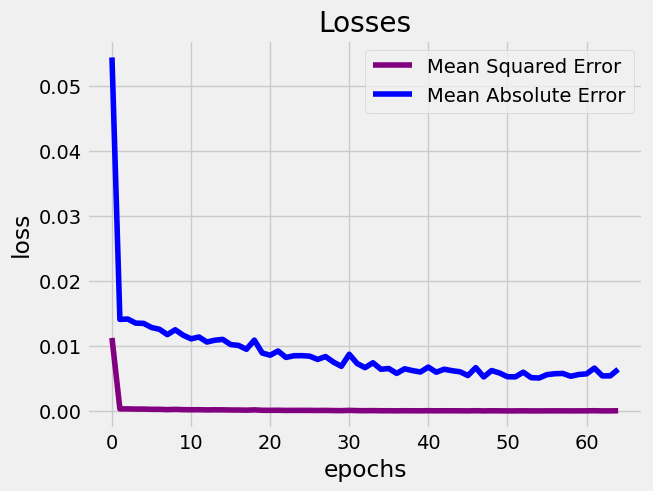

In [316]:
plt.plot(history.history["loss"],colors[0])
plt.plot(history.history["mean_absolute_error"],colors[2])
plt.legend(['Mean Squared Error','Mean Absolute Error'])
plt.title("Losses")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

In [317]:
x_test = []
y_test = []

for i in range(60, len(test)):
    x_test.append(test[i-60:i, 0])
    y_test.append(test[i, 0])
x_test, y_test = np.array(x_test), np.array(y_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [318]:
x_test.shape,y_test.shape

((1000, 60, 1), (1000,))

In [319]:
#inverse y_test scaling
predictions = model.predict(x_test)

#inverse predictions scaling
predictions = scaler.inverse_transform(predictions)
predictions.shape

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step


(1000, 1)

In [320]:
y_test = scaler.inverse_transform([y_test])

In [321]:
RMSE = np.sqrt(np.mean( y_test - predictions )**2).round(2)
RMSE

12.52

In [322]:
train = features.iloc[:train_size , 0:1]
test = features.iloc[train_size: , 0:1]
test['Predictions'] =predictions
test

,Price,Predictions
Date,,
2020-10-19,1908,1893.919678
2020-10-20,1912,1901.116211
2020-10-21,1926,1904.223145
2020-10-22,1902,1919.811401
2020-10-23,1902,1887.004761
...,...,...
2024-08-27,2575,2536.784180
2024-08-28,2560,2537.757812
2024-08-29,2583,2515.912598


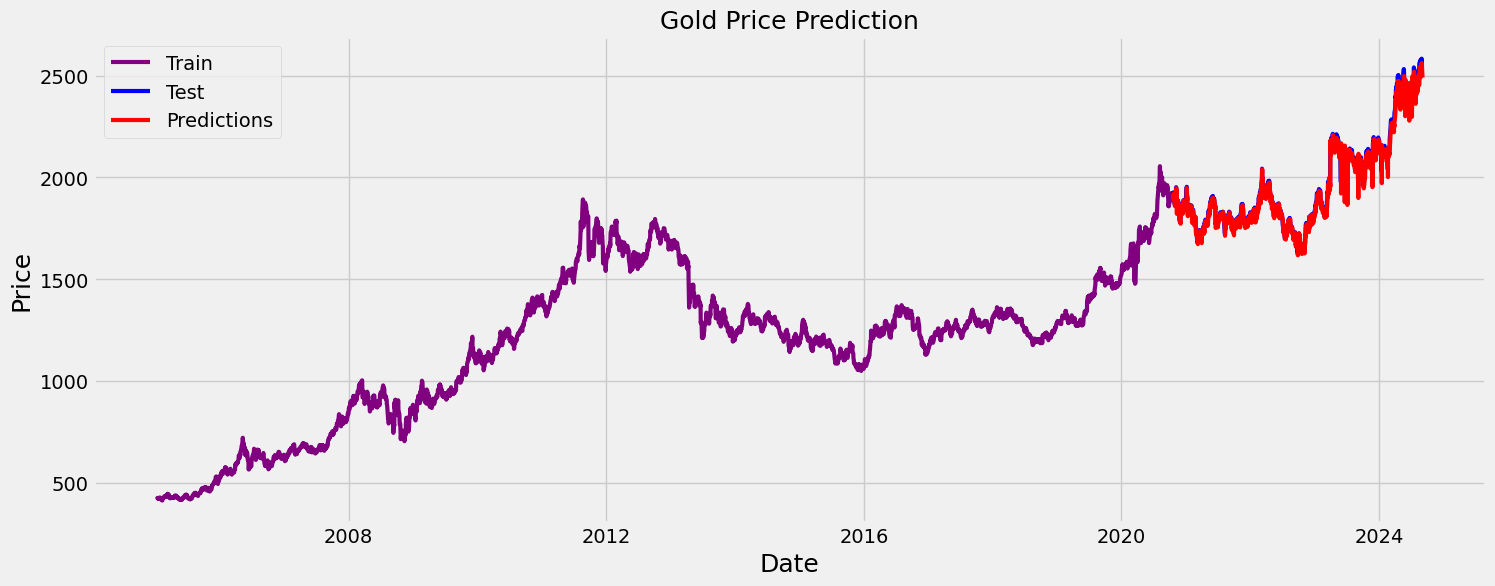

In [339]:
plt.figure(figsize= (16, 6))
plt.title('Gold Price Prediction', fontsize= 18)
plt.xlabel('Date', fontsize= 18)
plt.ylabel('Price', fontsize= 18)
plt.plot(train['Price'],colors[0] ,linewidth= 3)
plt.plot(test['Price'],colors[2] ,linewidth= 3)
plt.plot(test["Predictions"],colors[5] ,linewidth= 3)
plt.legend(['Train', 'Test', 'Predictions'])

In [341]:
def insert_end(Xin, new_input):
    timestep = 60
    for i in range(timestep - 1):
        Xin[:, i, :] = Xin[:, i+1, :]
    Xin[:, timestep - 1, :] = new_input
    return Xin

In [342]:
future = 90
forcast = []
Xin = x_test[-1 :, :, :]
time = []
for i in range(0, future):
    out = model.predict(Xin, batch_size=5)
    forcast.append(out[0, 0])
    print(forcast)
    Xin = insert_end(Xin, out[0, 0])
    time.append(pd.to_datetime(df.index[-1]) + timedelta(days=i))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
[0.42482942]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
[0.42482942, 0.42463073]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
[0.42482942, 0.42463073, 0.42443383]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
[0.42482942, 0.42463073, 0.42443383, 0.42423895]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
[0.42482942, 0.42463073, 0.42443383, 0.42423895, 0.42404574]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[0.42482942, 0.42463073, 0.42443383, 0.42423895, 0.42404574, 0.42385438]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[0.42482942, 0.42463073, 0.42443383, 0.42423895, 0.42404574, 0.42385438, 0.42366472]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
[0.42482942, 0.42463073, 0.42443383, 0.42423895, 0.42404574, 0.42385438, 0.42366472, 0.42347696]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
[0.42482942, 0.42463073, 0.42443383, 0.42423895, 0.42404574, 0.42385438, 0.42366472, 0.42347696, 0.42329085]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[0.42482942, 0.42463073, 0.42443383, 0.42423895, 0.42404574, 0.4238543

In [348]:
# Example of correct inverse transformation
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))
forecast = scaler.inverse_transform(forecast.reshape(-1, 1))

AttributeError: 'Series' object has no attribute 'reshape'

In [350]:
forcasted= scaler.inverse_transform(forcasted)

In [351]:
forcasted = pd.DataFrame(forcasted)
date = pd.DataFrame(time)
df_result = pd.concat([date,forcasted], axis=1)
df_result.columns = "Date", "Forecasted"

In [336]:
df_result

,Date,Forecasted
0,2024-09-03,1396.018188
1,2024-09-04,1395.040894
2,2024-09-05,1394.072021
3,2024-09-06,1393.111816
4,2024-09-07,1392.160156
...,...,...
85,2024-11-27,1337.670776
86,2024-11-28,1337.219238
87,2024-11-29,1336.771851
88,2024-11-30,1336.328857


### Fase 5: Evaluación

In [337]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate metrics
mse = mean_squared_error(y_test[0], predictions[:, 0])
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test[0], predictions[:, 0])

print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}")

MSE: 1104.50, RMSE: 33.23, MAE: 21.54


### Fase 5: Evaluación

MSE (Mean Squared Error): Es sensible a los errores grandes debido al cuadrado de las diferencias. Un valor de 1104.50 indica que hay cierta variabilidad entre las predicciones y los valores reales.

RMSE (Root Mean Squared Error): La raíz cuadrada del MSE, en este caso 33.23, permite interpretar el error en la misma escala que los datos originales. Este valor puede ser comparado con la escala de la variable 'Price'.

MAE (Mean Absolute Error): Es el promedio de los errores absolutos. Un valor de 21.54 indica que, en promedio, las predicciones están a esta distancia del valor real.